# Customer Churn Prediction

**Goal:** Predict which customers are likely to churn using the Telco Customer Churn dataset, and identify the key factors driving churn.

**Dataset:** 7,043 customers, 21 features (demographics, account info, services used, billing)

**Approach:** Data cleaning → EDA → Feature engineering → Model training (Logistic Regression, Random Forest) → Evaluation → Feature importance

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## **1. Load & Inspect Data** :
Loading the dataset and checking its shape, data types, and target class balance.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [3]:
print(df.shape)
print(df.dtypes)
print(df['Churn'].value_counts(normalize=True))

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


## **2. Data Cleaning** :
'TotalCharges' was stored as text due to blank values for new customers. Converting it to numeric and handling missing values.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.isnull().sum())
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1)
print(df.shape)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
(7032, 20)


## **3. Exploratory Data Analysis (EDA)** :
Looking at how churn varies across contract type, tenure, monthly charges, and internet service — to build intuition before modeling.

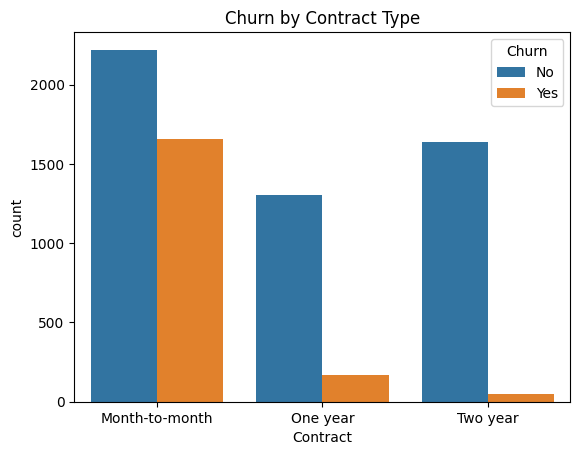

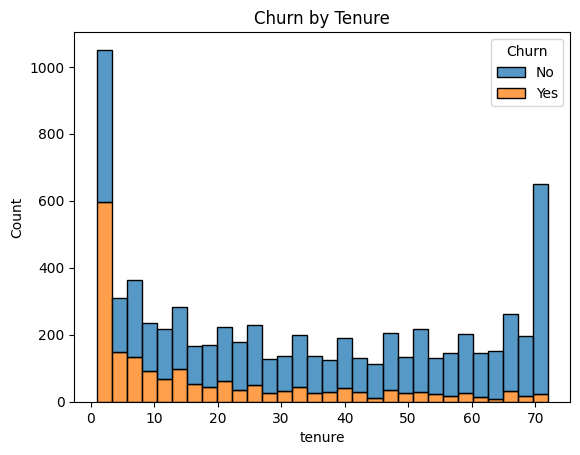

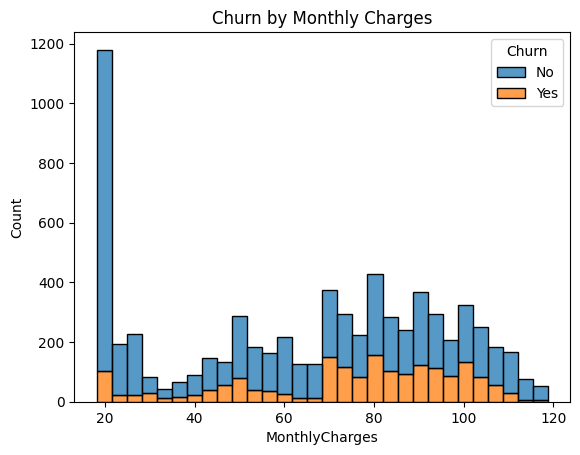

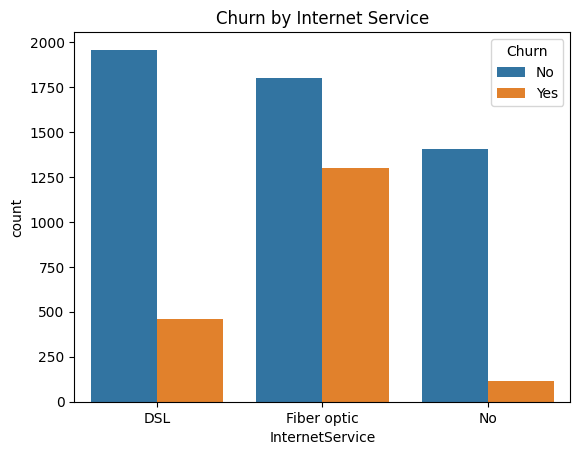

In [5]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Monthly Charges')
plt.show()

sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

## **4. Feature Engineering & Train/Test Split** :
Encoding categorical variables into numeric form and splitting the data into training and test sets (80/20), preserving the churn ratio in both.

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

X = pd.get_dummies(X, drop_first=True)
print(X.shape)
X.head()

(7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


## 5. Baseline Model: Logistic Regression
Training a simple, interpretable model first to establish a performance baseline.

In [8]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

[[916 117]
 [158 216]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8360972920365893


## 6. Stronger Model: Random Forest
Training a more powerful model to compare against the logistic regression model and see if performance improves.

In [9]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [10]:
y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

[[924 109]
 [186 188]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8194630664023069


## 7. Feature Importance
Identifying which factors most influence the model's churn predictions — this is often more valuable to the business than the prediction itself.

TotalCharges                      0.178580
tenure                            0.161990
MonthlyCharges                    0.151937
Contract_Two year                 0.060670
InternetService_Fiber optic       0.038928
PaymentMethod_Electronic check    0.037873
Contract_One year                 0.030572
OnlineSecurity_Yes                0.029054
gender_Male                       0.025515
PaperlessBilling_Yes              0.023523
dtype: float64


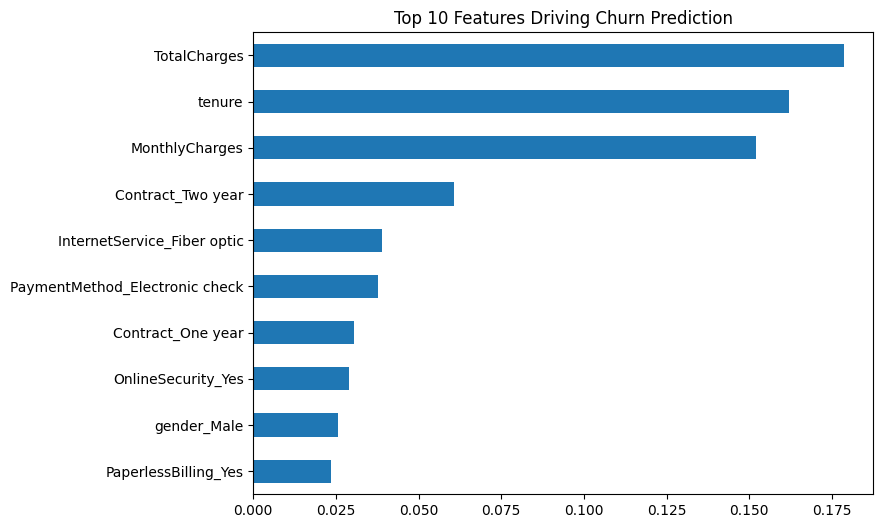

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))
plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Features Driving Churn Prediction')
plt.gca().invert_yaxis()
plt.show()

## Summary

- Built a churn prediction model using the Telco Customer Churn dataset (7,043 customers)
- Compared Logistic Regression (baseline) vs Random Forest
- **Logistic Regression performed better**: ROC-AUC of 0.836 vs 0.819 for Random Forest, and higher recall on churners (58% vs 50%)
- Key churn drivers (from feature importance): Total Charges, Tenure, Monthly Charges, Contract type, Internet Service type, and Payment Method
- Month-to-month contracts, short tenure, fiber optic internet, and electronic check payments are all associated with higher churn risk
- **Business recommendation**: Use Logistic Regression as the production model given its stronger recall and interpretability. Focus retention efforts on new customers and those on month-to-month contracts, and investigate service/pricing issues with fiber optic customers.
- **Limitation**: The model still misses ~42% of actual churners, suggesting room for improvement with additional features (e.g., customer support tickets, usage trends) in future work